Image size distribution:
  (48, 48): 25273 images
  (100, 100): 10420 images


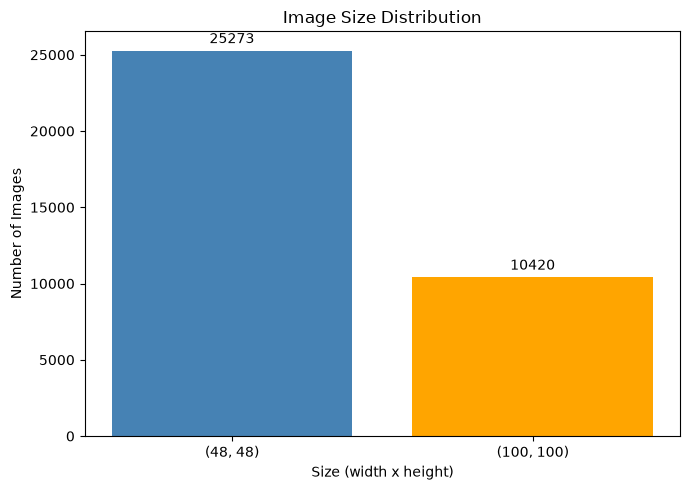

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

sizes = []

# Collect all image sizes
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            sizes.append(img.size)

# Count each unique size
size_counts = Counter(sizes)
print("Image size distribution:")
for size, count in size_counts.items():
    print(f"  {size}: {count} images")

# Plot size distribution
labels = [str(s) for s in size_counts.keys()]
values = list(size_counts.values())

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['steelblue', 'orange'])
plt.title('Image Size Distribution')
plt.xlabel('Size (width x height)')
plt.ylabel('Number of Images')
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

Image mode distribution:
  RGB: 30560 images
  L: 5133 images


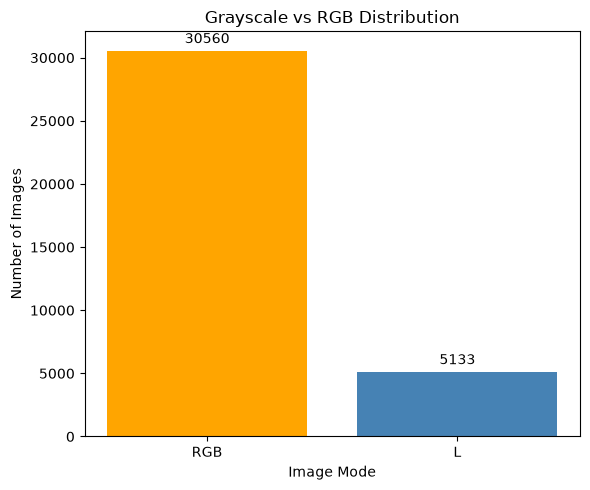

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

modes = []

# Collect all image modes (RGB or Grayscale)
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            modes.append(img.mode)

# Count each mode
mode_counts = Counter(modes)
print("Image mode distribution:")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count} images")

# Plot mode distribution
labels = list(mode_counts.keys())
values = list(mode_counts.values())
colors = ['steelblue' if l == 'L' else 'orange' for l in labels]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)
plt.title('Grayscale vs RGB Distribution')
plt.xlabel('Image Mode')
plt.ylabel('Number of Images')
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

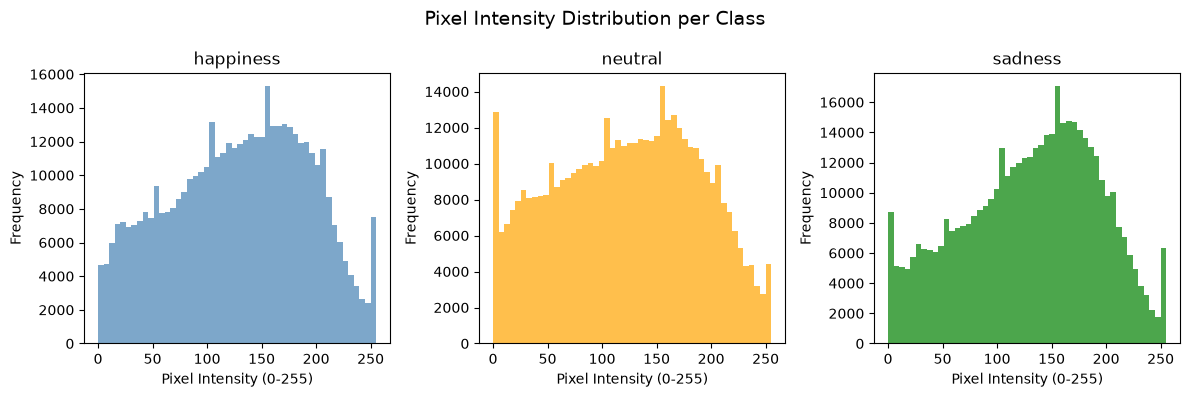

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

classes = ['happiness', 'neutral', 'sadness']
colors = ['steelblue', 'orange', 'green']

plt.figure(figsize=(12, 4))

# Plot pixel intensity histogram for each class
for idx, class_name in enumerate(classes):
    class_path = os.path.join(processed_path, 'train', class_name)
    pixel_values = []
    
    # Collect pixel values from 200 random images per class
    images = os.listdir(class_path)[:200]
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert('L')  # Convert to grayscale
        pixel_values.extend(np.array(img).flatten())
    
    plt.subplot(1, 3, idx + 1)
    plt.hist(pixel_values, bins=50, color=colors[idx], alpha=0.7)
    plt.title(f'{class_name}')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')

plt.suptitle('Pixel Intensity Distribution per Class', fontsize=14)
plt.tight_layout()
plt.show()


--- TRAIN ---
  happiness: 10801 images (34.6%)
  neutral: 10315 images (33.05%)
  sadness: 10097 images (32.35%)

--- TEST ---
  happiness: 1540 images (34.38%)
  neutral: 1516 images (33.84%)
  sadness: 1424 images (31.79%)


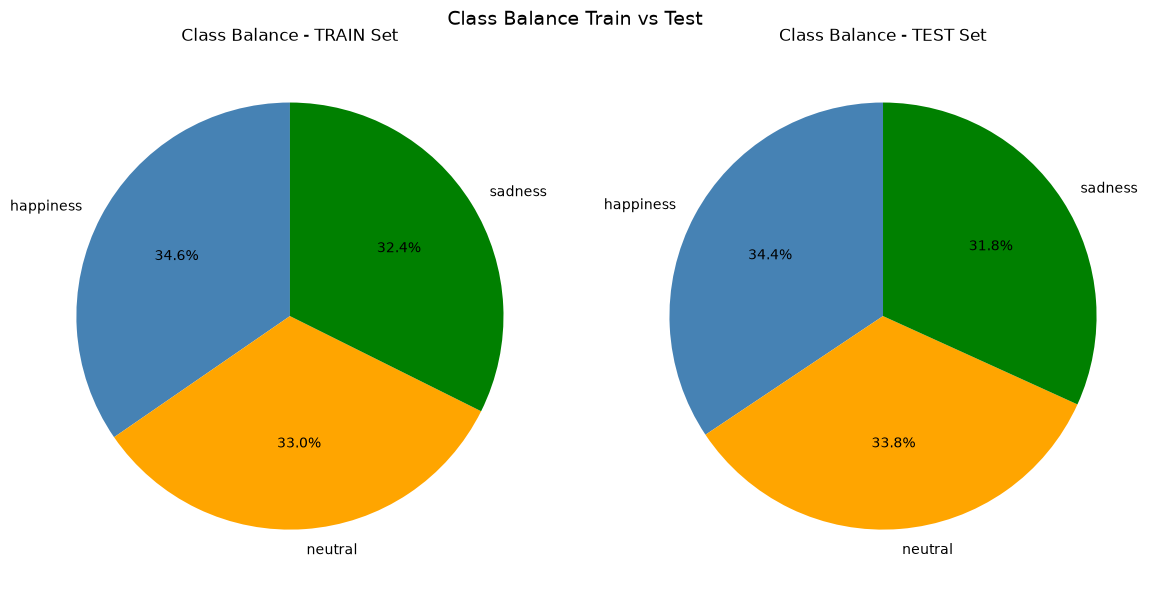

In [6]:
import os
import matplotlib.pyplot as plt

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

classes = ['happiness', 'neutral', 'sadness']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Calculate and plot both train and test side by side
for idx, (split, ax) in enumerate(zip(['train', 'test'], [ax1, ax2])):
    counts = []
    for class_name in classes:
        class_path = os.path.join(processed_path, split, class_name)
        counts.append(len(os.listdir(class_path)))
    
    total = sum(counts)
    percentages = [round((c / total) * 100, 2) for c in counts]
    
    print(f"\n--- {split.upper()} ---")
    for c, count, pct in zip(classes, counts, percentages):
        print(f"  {c}: {count} images ({pct}%)")
    
    ax.pie(percentages, labels=classes, autopct='%1.1f%%',
           colors=['steelblue', 'orange', 'green'], startangle=90)
    ax.set_title(f'Class Balance - {split.upper()} Set')

plt.suptitle('Class Balance Train vs Test', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import os
import numpy as np
from PIL import Image
from scipy import stats

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

classes = ['happiness', 'neutral', 'sadness']

# Calculate mean, median, mode, std per class
for class_name in classes:
    class_path = os.path.join(processed_path, 'train', class_name)
    pixel_values = []
    
    # Collect pixel values from all images
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert('L')  # Convert to grayscale
        pixel_values.extend(np.array(img).flatten())
    
    pixel_values = np.array(pixel_values)
    
    mean   = np.mean(pixel_values)
    median = np.median(pixel_values)
    mode   = stats.mode(pixel_values, keepdims=True)[0][0]
    std    = np.std(pixel_values)
    
    print(f"\n--- {class_name.upper()} ---")
    print(f"  Mean   : {mean:.2f}")
    print(f"  Median : {median:.2f}")
    print(f"  Mode   : {mode}")
    print(f"  Std Dev: {std:.2f}")


--- HAPPINESS ---
  Mean   : 126.71
  Median : 129.00
  Mode   : 143
  Std Dev: 59.54

--- NEUTRAL ---
  Mean   : 120.86
  Median : 122.00
  Mode   : 136
  Std Dev: 63.94

--- SADNESS ---
  Mean   : 122.21
  Median : 125.00
  Mode   : 255
  Std Dev: 63.52


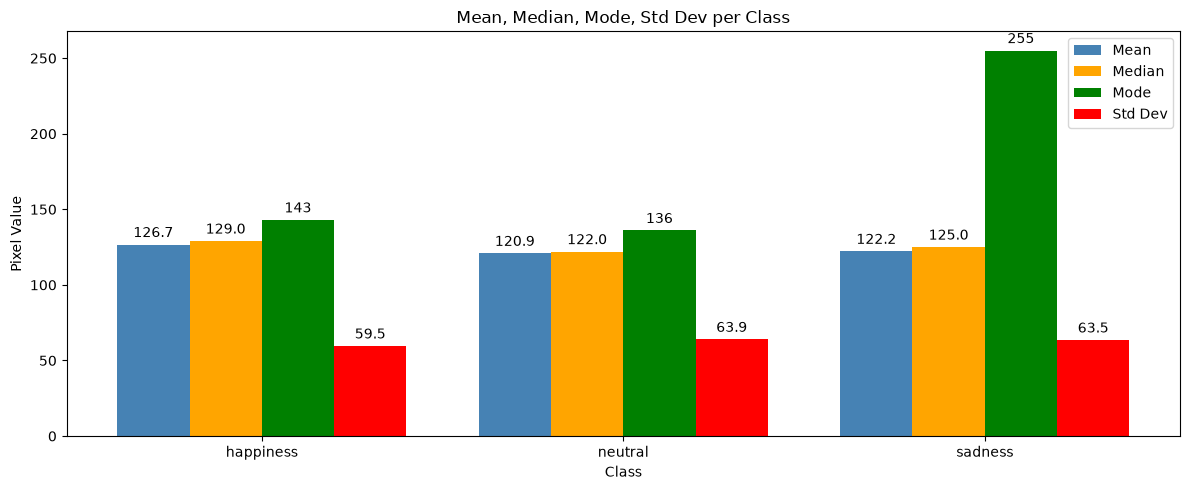

In [7]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['happiness', 'neutral', 'sadness']
means   = [126.71, 120.86, 122.21]
medians = [129.00, 122.00, 125.00]
modes   = [143, 136, 255]
stds    = [59.54, 63.94, 63.52]

x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))

# Plot mean, median, mode, std side by side
bars1 = ax.bar(x - 1.5*width, means,   width, label='Mean',    color='steelblue')
bars2 = ax.bar(x - 0.5*width, medians, width, label='Median',  color='orange')
bars3 = ax.bar(x + 0.5*width, modes,   width, label='Mode',    color='green')
bars4 = ax.bar(x + 1.5*width, stds,    width, label='Std Dev', color='red')

ax.set_xlabel('Class')
ax.set_ylabel('Pixel Value')
ax.set_title('Mean, Median, Mode, Std Dev per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(bars1, padding=3, fmt='%.1f')
ax.bar_label(bars2, padding=3, fmt='%.1f')
ax.bar_label(bars3, padding=3)
ax.bar_label(bars4, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()